In [1]:
import matplotlib.pyplot as plt
import numpy as np

from tomotok.core.phantoms import gauss_iso
from tomotok.core.geometry import generate_los, sparse_line, RegularGrid
from tomotok.core.derivative import all_direction_derivative_matrices
from tomotok.core.inversions import FastGevAlgebraic, FastSvdAlgebraic

In [2]:
grid = RegularGrid(50, 100, (.2, .7), (-.5, .5))

In [3]:
phantom = gauss_iso(grid.nr, grid.nz, cen=.3, amp=100)

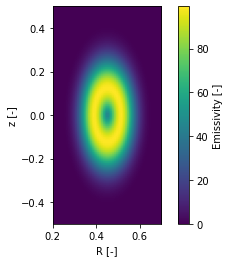

In [4]:
plt.figure()
plt.imshow(phantom, extent=grid.extent, origin='lower')
plt.colorbar(label='Emissivity [-]')
plt.xlabel('R [-]')
plt.ylabel('z [-]')
plt.show()

In [5]:
num = 20
s1, e1 = generate_los(num=(num, 1), fov=(70, 0), pinhole=(1, 0, 0), axis=(-1, 0, 0))
s2, e2 = generate_los(num=(num, 1), fov=(35, 0), pinhole=(.4, 0, .8), axis=(.1, 0, -1), length=1.5)
s3, e3 = generate_los(num=(num, 1), fov=(50, 0), pinhole=(.75, 0, -.4), axis=(-1, 0, 1), length=1.5)
s4, e4 = generate_los(num=(num, 1), fov=(50, 0), pinhole=(.75, 0, .4), axis=(-1, 0, -1), length=1.5)
s = np.concatenate((s1, s2, s3, s4))
e = np.concatenate((e1, e2, e3, e4))

In [6]:
gmat = sparse_line(s, e, grid, rmin=.2)

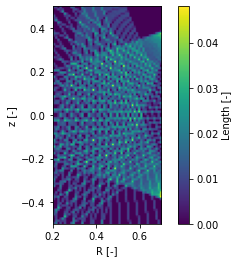

In [7]:
plt.figure()
plt.imshow(gmat.sum(0).reshape(grid.shape), extent=grid.extent, origin='lower')
plt.colorbar(label='Length [-]')
plt.xlabel('R [-]')
plt.ylabel('z [-]')
plt.show()

In [8]:
np.random.seed(20250506)
fwd = gmat @ phantom.flatten()
noise = 0.05 * fwd.max()
signal = fwd + np.random.normal(0, noise, fwd.shape)

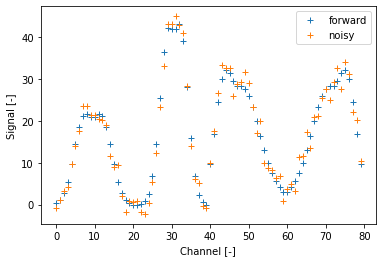

In [9]:
plt.figure()
plt.plot(fwd, '+', label='forward')
plt.plot(signal, '+', label='noisy')
plt.xlabel('Channel [-]')
plt.ylabel('Signal [-]')
plt.legend()
plt.show()

In [10]:
errors = (signal + signal.max() ) / 2 * .05
# errors = .001

### Derivative matrices

In [11]:
# Edge compensations (may) cause regularisation matrices not to be positive definite
# positive definiteness is required for the algebraic algorithms to work correctly
dmats = all_direction_derivative_matrices(grid, compensate_edges=False)

In [12]:
svd = FastSvdAlgebraic()  # no sparse optimization

In [13]:
out_svd, stats_svd = svd(signal, gmat, dmats, errors, method='median')

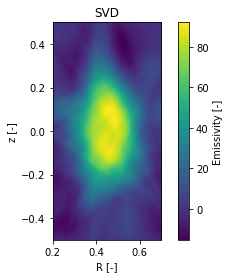

In [14]:
plt.figure()
plt.title('SVD')
plt.imshow(out_svd[0].reshape(grid.shape), origin='lower', extent=grid.extent)
plt.colorbar(label='Emissivity [-]')
plt.xlabel('R [-]')
plt.ylabel('z [-]')
plt.show()

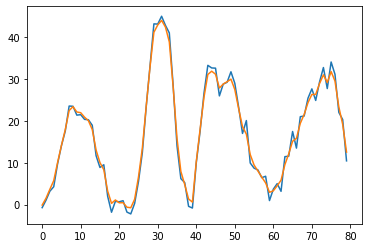

In [15]:
plt.figure()
plt.plot(signal)
plt.plot(gmat @ out_svd[0])
plt.show()

In [16]:
gev = FastGevAlgebraic()  # Uses methods from scipy.sparse

In [17]:
out_gev, stats_gev = gev(signal, gmat, dmats, errors, method='median')

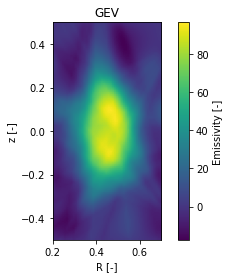

In [18]:
plt.figure()
plt.title('GEV')
plt.imshow(out_gev[0].reshape(grid.shape), origin='lower', extent=grid.extent)
plt.colorbar(label='Emissivity [-]')
plt.xlabel('R [-]')
plt.ylabel('z [-]')
plt.show()

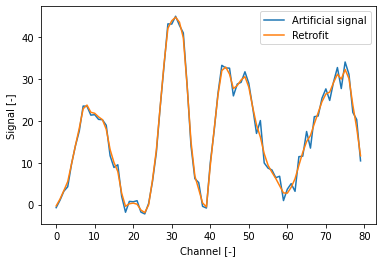

In [19]:
plt.figure()
plt.plot(signal, label='Artificial signal')
plt.plot(gmat @ out_gev[0], label='Retrofit')
plt.xlabel('Channel [-]')
plt.ylabel('Signal [-]')
plt.legend()
plt.show()

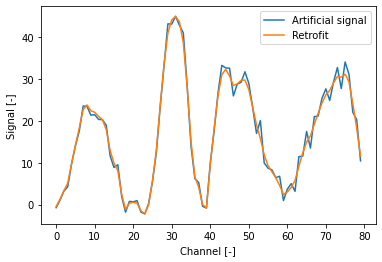

In [ ]:
plt.figure()
plt.plot(signal, label='Artificial signal')
plt.plot(gmat @ out_gev[0], label='Retrofit')
plt.xlabel('Channel [-]')
plt.ylabel('Signal [-]')
plt.legend()
plt.show()

In [ ]:
from scipy import sparse

In [ ]:
gmat_nrm = sparse.diags(1/errors, 0, shape=(gmat.shape[0], gmat.shape[0])) @ gmat

In [ ]:
# nweights = 1 / out_gev[0]
g = out_gev[0].copy()

for i in range(2):
    nweights = 1 / g
    nweights[nweights <= 0] = nweights.max()
    regmat = gev.regularisation_matrix(dmats, node_weights=nweights)
    gev.u, gev.s, gev.v = gev.decompose(gmat_nrm, regmat)
    alpha = gev.find_alpha(method='median')
    g = gev.series_expansion(alpha, signal/errors)

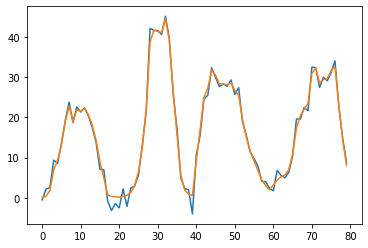

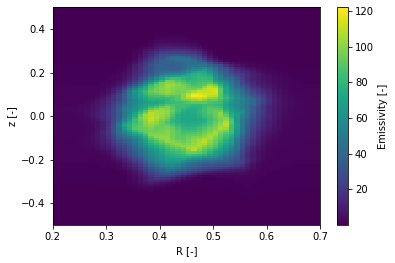

In [ ]:
plt.figure()
plt.plot(signal)
plt.plot(gmat @ g)

plt.figure()
plt.pcolormesh(*grid.border_mesh, g.reshape(grid.shape))
plt.colorbar(label='Emissivity [-]')
plt.xlabel('R [-]')
plt.ylabel('z [-]')
plt.show()
plt.show()
